In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
plt.rc('font',family='Malgun Gothic' )
!pip install koreanize-matplotlib
from IPython.display import display
import koreanize_matplotlib
import seaborn as sns


�׼����� �źεǾ����ϴ�.


In [224]:
origin_train=pd.read_csv("train.csv")
origin_test=pd.read_csv("test.csv")
data_train=origin_train.copy()
data_test=origin_test.copy()


In [225]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [227]:
data_test

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30/11/2018,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,NaN,No Holiday,Yes
716,30/11/2018,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,30/11/2018,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,30/11/2018,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# 기상청 데이터를 이용해 결측치 채우기
 * https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36
 * https://www.weather.go.kr/w/resources/pdf/kma_data_portal_guide.pdf
 * 일단 이 데이터로 결측치를 채우기 적절한지 판단하기 위해 2가지 정도 생각해볼 수 있다.
   1. 결측치를 제외한 나머지 값들이 모두 동일한가?
   2. 결측치 부분에 적절한 값이 들어가 있는가?
   

In [228]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8040 non-null   object 
 1   Rented Bike Count          8040 non-null   int64  
 2   Hour                       8040 non-null   int64  
 3   Temperature(째C)            7240 non-null   float64
 4   Humidity(%)                8040 non-null   int64  
 5   Wind speed (m/s)           7238 non-null   float64
 6   Visibility (10m)           8040 non-null   int64  
 7   Dew point temperature(째C)  8040 non-null   float64
 8   Solar Radiation (MJ/m2)    8040 non-null   float64
 9   Rainfall(mm)               8040 non-null   float64
 10  Snowfall (cm)              8040 non-null   float64
 11  Seasons                    7238 non-null   object 
 12  Holiday                    8040 non-null   object 
 13  Functioning Day            8040 non-null   objec

In [229]:
data_train.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(째C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(째C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

In [230]:
print(data_train.isnull().sum())
print(data_test.isnull().sum())

Date                           0
Rented Bike Count              0
Hour                           0
Temperature(째C)              800
Humidity(%)                    0
Wind speed (m/s)             802
Visibility (10m)               0
Dew point temperature(째C)      0
Solar Radiation (MJ/m2)        0
Rainfall(mm)                   0
Snowfall (cm)                  0
Seasons                      802
Holiday                        0
Functioning Day                0
dtype: int64
Date                          0
Hour                          0
Temperature(째C)              76
Humidity(%)                   0
Wind speed (m/s)             74
Visibility (10m)              0
Dew point temperature(째C)     0
Solar Radiation (MJ/m2)       0
Rainfall(mm)                  0
Snowfall (cm)                 0
Seasons                      74
Holiday                       0
Functioning Day               0
dtype: int64


### Rented Bike Count ###

<Axes: xlabel='Rented Bike Count', ylabel='Count'>

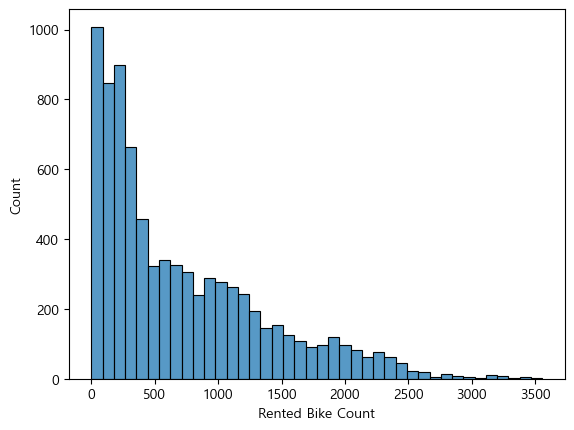

In [231]:
sns.histplot(data_train['Rented Bike Count'], bins=40)

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

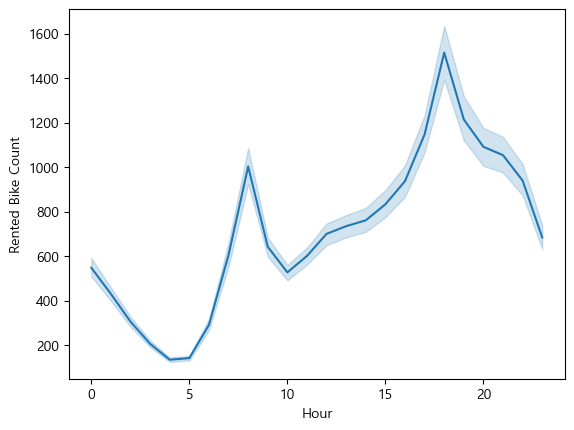

In [232]:
sns.lineplot(
    data=data_train,
    x='Hour',
    y='Rented Bike Count',
    estimator='mean'
)

<Axes: xlabel='Temperature(째C)', ylabel='Rented Bike Count'>

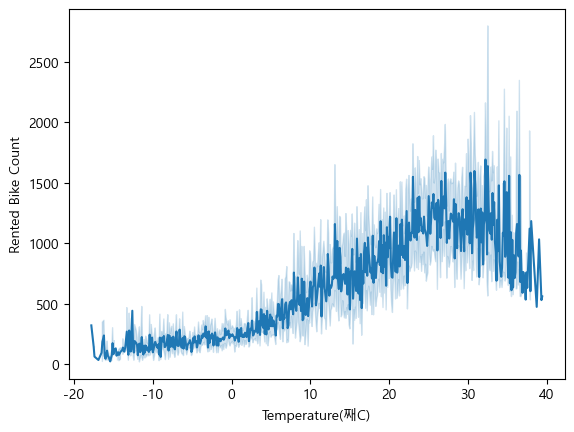

In [235]:
sns.lineplot(
    data=data_train,
    x='Temperature(째C)',
    y='Rented Bike Count',
    estimator='mean'
)


<Axes: xlabel='Functioning Day', ylabel='Rented Bike Count'>

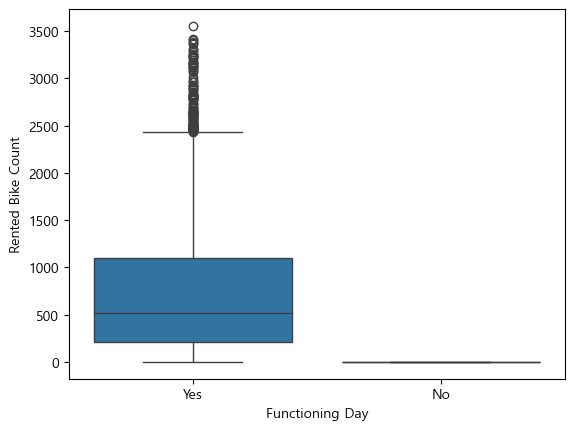

In [236]:
sns.boxplot(
    data=data_train,
    x='Functioning Day',
    y='Rented Bike Count'
)


## 결측치 채우기 ##

In [38]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

target_col = 'Rented Bike Count'

In [ ]:

display(train.head())
display(test.head())

train.info()
test.info()

print('train columns:', list(train.columns))
print('test  columns:', list(test.columns))

print('\n[Missing values - train]')
display(train.isnull().sum().sort_values(ascending=False))

print('\n[Missing values - test]')
display(test.isnull().sum().sort_values(ascending=False))

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8040 non-null   object 
 1   Rented Bike Count          8040 non-null   int64  
 2   Hour                       8040 non-null   int64  
 3   Temperature(째C)            7240 non-null   float64
 4   Humidity(%)                8040 non-null   int64  
 5   Wind speed (m/s)           7238 non-null   float64
 6   Visibility (10m)           8040 non-null   int64  
 7   Dew point temperature(째C)  8040 non-null   float64
 8   Solar Radiation (MJ/m2)    8040 non-null   float64
 9   Rainfall(mm)               8040 non-null   float64
 10  Snowfall (cm)              8040 non-null   float64
 11  Seasons                    7238 non-null   object 
 12  Holiday                    8040 non-null   object 
 13  Functioning Day            8040 non-null   objec

Wind speed (m/s)             802
Seasons                      802
Temperature(째C)              800
Rented Bike Count              0
Hour                           0
Date                           0
Humidity(%)                    0
Visibility (10m)               0
Solar Radiation (MJ/m2)        0
Dew point temperature(째C)      0
Rainfall(mm)                   0
Snowfall (cm)                  0
Holiday                        0
Functioning Day                0
dtype: int64


[Missing values - test]


Temperature(째C)              76
Wind speed (m/s)             74
Seasons                      74
Hour                          0
Date                          0
Humidity(%)                   0
Visibility (10m)              0
Solar Radiation (MJ/m2)       0
Dew point temperature(째C)     0
Rainfall(mm)                  0
Snowfall (cm)                 0
Holiday                       0
Functioning Day               0
dtype: int64

,column,0값 개수(결측 의심),NaN 개수,총 데이터 수
9,Snowfall (cm),7648,0,8040
8,Rainfall(mm),7529,0,8040
7,Solar Radiation (MJ/m2),3890,0,8040
1,Hour,335,0,8040
0,Rented Bike Count,223,0,8040
4,Wind speed (m/s),53,802,8040
6,Dew point temperature(째C),45,0,8040
2,Temperature(째C),17,800,8040
3,Humidity(%),17,0,8040
5,Visibility (10m),0,0,8040


## Temperature 결측치 채우기 ##


# **기온 결측치 채우기**
![설명](이슬점공식.png)

- Dewpoint = 이슬점
- T = 기온
- RH = humidity

## 결측치 채우기 
- train데이터와 원본데이터가 일치하는지 확인

In [133]:
df_original=pd.read_csv("C:/Users/happi/OneDrive/문서/baf-fresh-edu-18/OBS_ASOS_TIM_20260206164933.csv",encoding="cp949")

In [85]:
df_original

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),일조(hr),적설(cm)
0,108,서울,2017-12-01 00:00,-5.2,NaN,2.2,37,NaN,NaN
1,108,서울,2017-12-01 01:00,-5.5,NaN,0.8,38,NaN,NaN
2,108,서울,2017-12-01 02:00,-6.0,NaN,1.0,39,NaN,NaN
3,108,서울,2017-12-01 03:00,-6.2,NaN,0.9,40,NaN,NaN
4,108,서울,2017-12-01 04:00,-6.0,NaN,2.3,36,NaN,NaN
...,...,...,...,...,...,...,...,...,...
8035,108,서울,2018-10-31 19:00,8.4,NaN,1.0,53,NaN,NaN
8036,108,서울,2018-10-31 20:00,7.6,NaN,0.7,59,NaN,NaN
8037,108,서울,2018-10-31 21:00,7.6,NaN,3.0,59,NaN,NaN
8038,108,서울,2018-10-31 22:00,6.8,NaN,2.2,58,NaN,NaN


In [52]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지점       8040 non-null   int64  
 1   지점명      8040 non-null   object 
 2   일시       8040 non-null   object 
 3   기온(°C)   8040 non-null   float64
 4   풍속(m/s)  8016 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 314.2+ KB


In [65]:
print("원본 데이터 shape :", df_original.shape)
print("train 데이터 shape :", data_train.shape)

원본 데이터 shape : (8040, 5)
train 데이터 shape : (8040, 14)


### temperature 결측치 채우기 ###

In [237]:
#기온 데이터 결측치 개수 확인
data_train['Temperature(째C)'].isna().sum()

np.int64(800)

In [238]:
#temperature가 결측치인 위치를 True/False 마스크로 생성- 결측치가 있는 행만 골라서 계산하려고
mask = data_train['Temperature(째C)'].isna()
mask.sum()

np.int64(800)

In [239]:
Dewpoint = data_train.loc[mask, 'Dew point temperature(째C)']
RH = data_train.loc[mask, 'Humidity(%)']

In [240]:
a = 17.62
b = 243.12
C = (a * Dewpoint) / (b + Dewpoint) - np.log(RH / 100)

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [241]:
data_train.loc[mask, 'Temperature(째C)'] = (b * C) / (a - C)
data_train['Temperature(째C)'].isna().sum()

np.int64(1)

In [242]:
data_train.loc[
    data_train['Temperature(째C)'].isna(),
    ['Date', 'Hour', 'Wind speed (m/s)',
     'Dew point temperature(째C)', 'Humidity(%)', 'Temperature(째C)']
]

,Date,Hour,Wind speed (m/s),Dew point temperature(째C),Humidity(%),Temperature(째C)
4131,22/05/2018,3,0.7,10.4,0,NaN


- 상대습도가 0인 1개의 관측치는 로그 연산이 불가하므로 여전히 NAN값 1개가 존재한다. 
- 잔여 1개의 결측치는 기상청 데이터를 이용하여 대체하였다.

In [247]:
# 2018-05-22 03:00 기온 15.5, 습도 72
mask_temp_na = data_train['Temperature(째C)'].isna()

data_train.loc[mask_temp_na, 'Temperature(째C)'] = 15.5
data_train.loc[mask_temp_na, 'Humidity(%)'] = 72

In [248]:
data_train['Temperature(째C)'].isna().sum()

np.int64(0)

### wind speed 결측치 ###

In [164]:
df_original=pd.read_csv("C:/Users/happi/OneDrive/문서/baf-fresh-edu-18/OBS_ASOS_TIM_20260206164933.csv",encoding="cp949")


In [ ]:
df_original.isnull().sum() #기상청 데이터 결측치 24개

지점            0
지점명           0
일시            0
기온(°C)        0
강수량(mm)    7150
풍속(m/s)      24
습도(%)         0
일조(hr)     3595
적설(cm)     7648
dt            0
dtype: int64

In [258]:
data_train['Wind speed (m/s)'].isnull().sum()  # train 데이터셋에 결측치 802개

np.int64(802)

In [ ]:
(data_train['Wind speed (m/s)'] == df_original['풍속(m/s)']).value_counts() #같지 않은 값이 824개

True     7216
False     824
Name: count, dtype: int64

In [262]:
((data_train['Wind speed (m/s)'].isna())&(df_original['풍속(m/s)'].isna())).sum() #기상청으로 대체하더라도 2개가 남을 것

np.int64(2)

In [263]:
print(data_train['Wind speed (m/s)'].head(10))
mask = data_train['Wind speed (m/s)'].isna()
data_train.loc[mask, 'Wind speed (m/s)'] = df_original.loc[mask, '풍속(m/s)']
print(data_train['Wind speed (m/s)'].head(10))

0    2.2
1    0.8
2    1.0
3    0.9
4    NaN
5    1.5
6    1.3
7    0.9
8    1.1
9    0.5
Name: Wind speed (m/s), dtype: float64
0    2.2
1    0.8
2    1.0
3    0.9
4    2.3
5    1.5
6    1.3
7    0.9
8    1.1
9    0.5
Name: Wind speed (m/s), dtype: float64


In [ ]:
data_train['Wind speed (m/s)'].isnull().sum() #2개의 결측치를 그 날짜 풍속 평균으로 대체

np.int64(2)

In [265]:
data_train.groupby('Date')['Wind speed (m/s)'].transform('mean')

0       1.537500
1       1.537500
2       1.537500
3       1.537500
4       1.537500
          ...   
8035    1.666667
8036    1.666667
8037    1.666667
8038    1.666667
8039    1.666667
Name: Wind speed (m/s), Length: 8040, dtype: float64

In [266]:
data_train['Wind speed (m/s)'] = data_train['Wind speed (m/s)'].fillna(
    data_train.groupby('Date')['Wind speed (m/s)'].transform('mean')
)

In [267]:
data_train['Wind speed (m/s)'].isnull().sum()

np.int64(0)

### seasons 결측치 전처리 ###


In [272]:
# Date를 datetime으로 바꾸기
date_dt = pd.to_datetime(data_train['Date'], dayfirst=True, errors='coerce')

# 월만 따로 뽑기
month = date_dt.dt.month

# Seasons가 비어있는(NaN) 행만 선택
mask = data_train['Seasons'].isna()

# 결측치인 Seasons를 월 기준으로 채우기
data_train.loc[mask & month.isin([3,4,5]), 'Seasons'] = 'Spring'   # 3~5월 → 봄
data_train.loc[mask & month.isin([6,7,8]), 'Seasons'] = 'Summer'   # 6~8월 → 여름
data_train.loc[mask & month.isin([9,10,11]), 'Seasons'] = 'Autumn' # 9~11월 → 가을
data_train.loc[mask & month.isin([12,1,2]), 'Seasons'] = 'Winter'  # 12~2월 → 겨울

# Seasons 결측치가 남아있는지 확인
data_train['Seasons'].isna().sum()


np.int64(0)

In [273]:
data_train.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(째C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(째C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

- 그래프 그려보기

<Axes: xlabel='Seasons', ylabel='Temperature(째C)'>

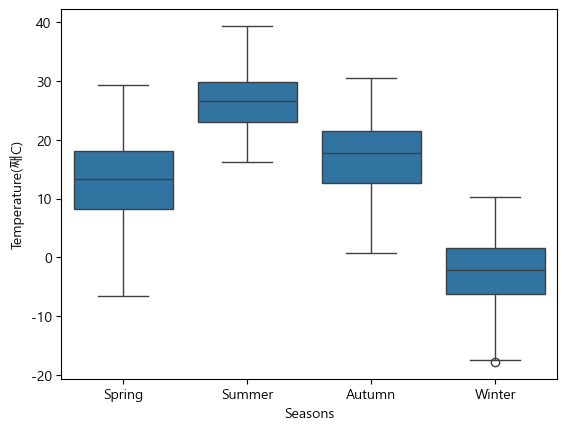

In [274]:
sns.boxplot(
    x='Seasons',
    y='Temperature(째C)',
    data=data_train,
    order=['Spring', 'Summer', 'Autumn', 'Winter']
)

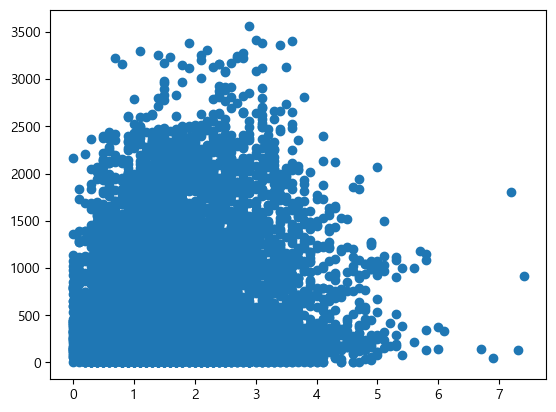

In [196]:
plt.scatter(x=data_train['Wind speed (m/s)'],y=data_train['Rented Bike Count'])

## 모델링 ##

In [290]:
data_train.drop(columns=['Date'], inplace=True)

In [291]:
data_train = pd.get_dummies(data_train, 
                            columns=['Seasons','Holiday','Functioning Day'], 
                            drop_first=True)+0
data_train

,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,0,1,1,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,1507,19,8.4,53,1.0,2000,-0.6,0.0,0.0,0.0,0,0,0,1,1
8036,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,0,0,0,1,1
8037,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,0,0,0,1,1
8038,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,0,0,0,1,1


- 선형회귀모델

In [292]:
Y_train = data_train['Rented Bike Count']
X_train = data_train.drop(['Rented Bike Count'], axis=1, inplace=False)

In [293]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [294]:
model_linear = LinearRegression()
model_linear.fit(X_train, Y_train)

LinearRegression()

In [295]:
from sklearn.metrics import r2_score, mean_squared_error

In [296]:
def eval_regression(model_linear):
    Y_train_pred = model_linear.predict(X_train)
    print('학습 능력')
    print('R Square : ', r2_score(Y_train, Y_train_pred))
    print('MSE : ', mean_squared_error(Y_train, Y_train_pred))

In [297]:
eval_regression(model_linear)

학습 능력
R Square :  0.5575494225954005
MSE :  191146.0109340825


In [298]:
scaling_model = make_pipeline(StandardScaler(),LinearRegression())
scaling_model.fit(X_train, Y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [299]:
eval_regression(scaling_model)

학습 능력
R Square :  0.5575494225954007
MSE :  191146.01093408244


In [300]:
scaling_coef = scaling_model.named_steps["linearregression"].coef_
scaling_coef

array([ 197.27133126,  216.9768322 , -217.02081884,   19.41584848,
         -3.21697573,   99.28614883,  -73.10799641,  -68.85600387,
         24.25883945,  -80.32934378,  -73.05472325, -201.89611315,
         26.58119949,  162.49727146])

- 랜덤포레스트

In [302]:
from sklearn.ensemble import RandomForestRegressor

In [304]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [312]:
eval_regression(rf)

학습 능력
R Square :  0.9832197203553321
MSE :  7249.359996887438


In [313]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate_df(model, X, y, model_name):
    y_pred = model.predict(X)
    return {
        'Model': model_name,
        'R2': r2_score(y, y_pred),
        'MSE': mean_squared_error(y, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y, y_pred))
    }

In [314]:
results = pd.DataFrame([
    evaluate_df(model_linear, X_train, Y_train, 'Linear Regression'),
    evaluate_df(scaling_model, X_train, Y_train, 'Linear Regression (Scaled)'),
    evaluate_df(rf, X_train, Y_train, 'Random Forest')
])

results

,Model,R2,MSE,RMSE
0,Linear Regression,0.557549,191146.010934,437.202483
1,Linear Regression (Scaled),0.557549,191146.010934,437.202483
2,Random Forest,0.983220,7249.359997,85.143174



- rmse:큰 오차에 더 패널티를 주는 지표..즉 랜덤 포레스트가 상대적으로 큰 오차를 더 잘 억제
- R Square: 결정계수 또한 랜덤 포레스트가 더 높음

- 랜덤포레스트 모델은 비선형 관계와 변수 간 상호작용을 잘 학습한다.
-> 날씨, 시간, 계절처럼 복잡하게 얽힌 패턴을 선형 가정 없이도 잘 잡아낸다.

- 과적합에 비교적 강하고 예측 성능이 안정적이다
-> 여러 결정트리를 앙상블로 사용해 개별 트리의 오류를 평균화한다.